# How to use the DCCLab Python module : A guide to image analysis


## Introduction
Image analysis has a very important role in science. In recent years, lots of new methods were developped to help us with this often huge and time consuming task. This is why we thougth it would be a great idea to create a Python module that regroup some of the most common methods used when handling images. `dcclab` is a user-oriented module developped by Danel Côté's DCCLab group. The main purpose of `dcclab` is to be easy to use and straigthforward without having to use different modules because one offers some special methods that others don't.

Disclaimer : The following tutorial is not exhaustive of everything the module can do. `dcclab` is still a work in progress and major parts of it may change in the future.

## Reading a file
Probably the most basic action to do in image processing. There is A LOT of image files existing around the globe. Some of them are convenient for upload/download purpose because of their compression, while others are quite heavy and contain a lot of untouched data. A the moment these lines were written, `dcclab` can read most common files such as `.png` or `.jpg`. It can also read fancier stuff like Carl Zeiss Microscopy Files (`.czi`), Tagged Image File Format (`.tif`, `.tiff`) and Leica Image File Format (`.lif`). For the first part of this tutorial, let's first of all import the essential packages:

In [88]:
import dcclab as dcc # There it is, the dcclab module
import os # Easier to handle paths with this one
import numpy as np # For matrix handling and computations
import cv2 as cv # For later
import matplotlib.pyplot as plt # For display purpose
plt.rcParams['figure.figsize'] = [10, 5]

Now, we can read files with `dcclab`. Let's open a `.czi` file:

In [89]:
path = os.path.join(os.path.dirname(os.path.dirname(os.getcwd())), "tests", "testData", "testCziFile.czi") # Let's go to
# our test folder with all the test data and select a specific file
czi = dcc.Image(path=path) # We use the Image class form dcclab to read the file

The `Image` class gives us an instance of `Image` and with this object we can do some basic handling:

## Working with channels instead of whole images
First of all, let's take a look at `Image`. The class itself cannot do a lot, but `Image` is fundamental.

In [90]:
czi.sizeInBytes

11306240

In [91]:
czi.shape

(1936, 1460, 2)

We can see that when we call `shape`, we get the shape of the matrix containing our pixels. In this example, we have a file with 2 channels (the last element of the tuple), a height of 1460 pixels and a width of 1936 pixels. Knowing this, we can work on single channel if we want.

Why can we work with single channel? Because we did the module with the fact that an image is composed of X number of channels (most of the time it is 3 channels, like `.jpg` files, but `.png` can handle 4 channels. The 4th channel is the trasparency of the image). With this in mind, an `Image` object is composed of some `Channel` objects, which are the basis of our module. Most of the computation is done on single `Channel`. Let's work with our two channels, but separated:

In [92]:
firstChannel = czi[0] # We can access a single channel with indexing
secondChannel = czi[1]

Let's display them:

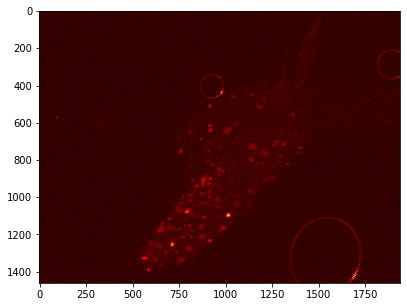

In [93]:
_=firstChannel.display(colorMap="hot") # We can specify the color map. It is 'jet' by default. We put _ = because
# this methods returns the current object and we don't want it to be printed in this notebook. Feel free to remove it
# if you want

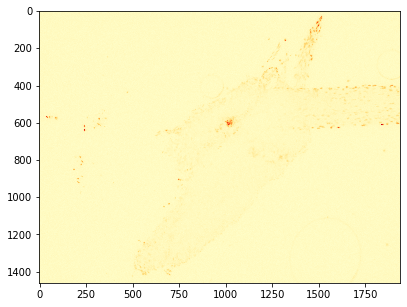

In [94]:
_=secondChannel.display(colorMap="YlOrRd")

"Can we display both of them on the same display?" Sure!

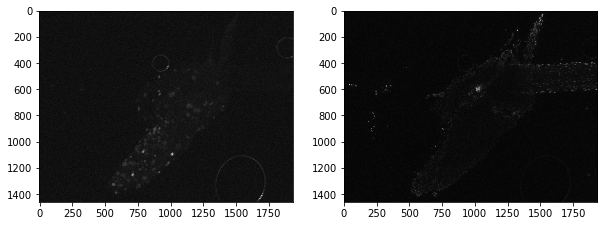

In [95]:
_=dcc.Channel.multiChannelDisplay([firstChannel, secondChannel], ["gray"])

`multiChannelDisplay` is a static method from the `Channel` class, this is why it doesn't need a specific instance of `Channel` in order to work. It takes 2 arguments : The first one is a list of `Channel` instances, while the second one is a list of color maps. It is important to remember that the list of color maps is optional, but when given, it must either have only one element (applied to every channel) or have as element as there are channels.

## It's quite nice to display channels, but can we do something more *useful*?
**YES YOU CAN**! The purpose of `dcclab` is not just about displaying stuff... there is a ton of apps that do just that! `Channel` class offers a lot of methods varying from global entropy of the channel to spectral filtering and Fourier transform. Let's start with some basic high school maths on our channels:

In [96]:
firstChannel.getAverageValueOfPixels() # Computes the average value of the pixels

133.27654640269444

In [97]:
secondChannel.getMedian() # Computes the median

75.0

In [98]:
firstChannel.getExtrema() # Finds the minimum and the maximum values of the channel

(64, 1047)

In [99]:
secondChannel.getMaximum() # Finds the (X, Y) position of pixels with the maximum intensity

[(1837, 608)]

There are a few more methods that can be used to extract basic stats about a single channel, it is left to the reader to try them out! Let's move on to heavier stuff: let's compute the histogram!

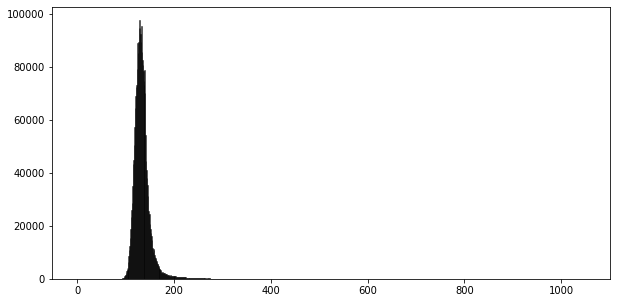

In [100]:
_=firstChannel.displayHistogram() # Displays the histogram of the channel

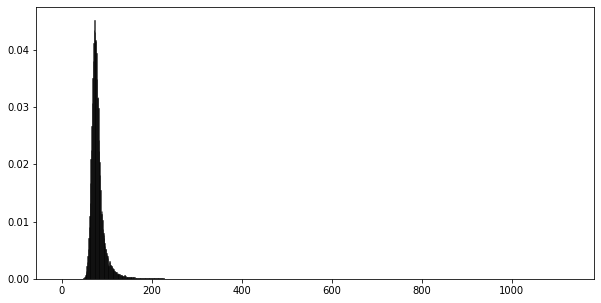

In [102]:
_=secondChannel.displayHistogram(normed=True) # Displays the normalized histogram of the channel

There is another method, called `getHistogramValues()` which only computes the values and doesn't display the whole histogram. It can be used for various reasons, such as thresholding techniques or histogram equalization.

## But can we do more *intense* stuff?
Again, **YES YOU CAN**! Like I said earlier, histograms are useful when we want to apply thresholding techniques, such as Otsu's method or isodata thresholding. These two methods are part of the module, as well as other thresholding methods such as global thresholding (with an arbitrary value) or local/adaptive thresholding. Let's take a look at some of them:

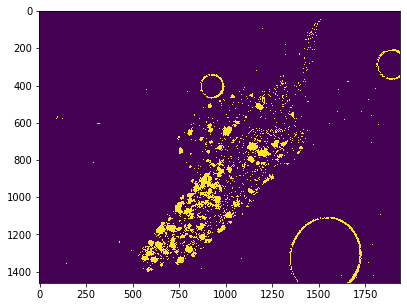

In [103]:
thresholdOtsu = firstChannel.getOtsuThresholding() # Thresholds the original channel according to Otsu's methods
# and returns a new one
_=thresholdOtsu.display()

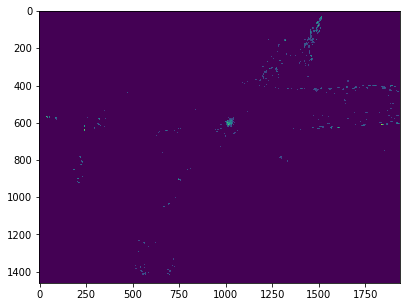

In [104]:
thresholdGlobal = secondChannel.getGlobalThresholding(201) # Thresholds the original array according to a given value
_=thresholdGlobal.display()

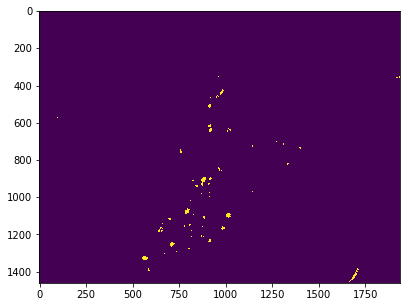

In [105]:
adaptiveMean = firstChannel.getAdaptiveThresholdMean(59) # Localy thresholds the original channel with a kernel. The size
# of the kernel is given by the sole parameter of this method. The size must be odd
_=adaptiveMean.display()

Thresholding an image is the most basic way to segment it. But in order to get a good segmentation, the image needs to be "clean" (i.e. not a lot of noise). Let's continue with some simulated images of circles representing cells.

In [106]:
def generateCircles(arrayShape:tuple, nbCircles:int, radiusAvg:float, radiusStdDev:float) -> np.ndarray:
    array = np.zeros(arrayShape)
    radii = []
    positions = set()
    while len(positions) < nbCircles:
        tempRadius = np.random.normal(radiusAvg, radiusStdDev)
        tempsRadius = abs(np.ceil(tempRadius))
        tempX = np.random.choice(range(arrayShape[1] + 1))
        tempY = np.random.choice(range(arrayShape[0] + 1))
        positions.add((tempX, tempY))
        radii.append(tempRadius)
    for i in range(nbCircles):
        cv.circle(array, positions.pop(), int(radii[-(i+1)]), 1, -2)
    return array

In [107]:
simulation = generateCircles((1000, 1000), 100, 5.8, 2.3)

Now let's create an `Image` instance with that simulated array.

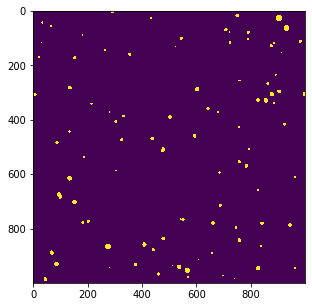

In [108]:
simulatedImage = dcc.Image(simulation)
simulatedImage.display()

In [109]:
simulatedChannel = simulatedImage[0]

We can apply some noise to the channel with two methods from the `Channel` class.

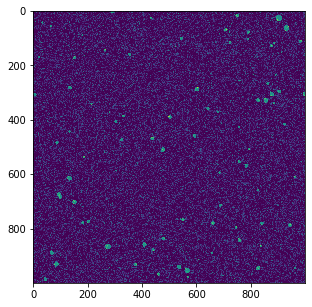

In [110]:
noisySimulatedChannel = simulatedChannel.applyGaussianNoise(sigma=0.3, mean=0) # Specify the standard deviation and the
# mean of the gaussian distribution used for the noise. If the image is normalized, normally the mean is 0. The standard
# deviation should be small, near 1/10 of the image's average.
_=noisySimulatedChannel.display()

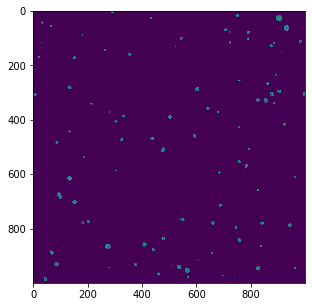

In [111]:
noisySimulatedChannel2 = simulatedChannel.applyPoissonNoise(10)
_=noisySimulatedChannel2.display()

Let's denoise `noisySimulatedChannel` with different algorithms.

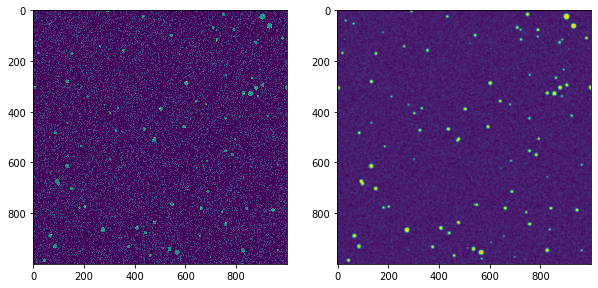

In [112]:
gaussianFilter = noisySimulatedChannel.getGaussianFilter(sigma=2) # The `sigma` parameter represent the standard deviation
# of the gaussian kernel.
_=dcc.Channel.multiChannelDisplay([noisySimulatedChannel, gaussianFilter])

We can see that it is better, but can be improved. Let's try with another value of standard deviation:

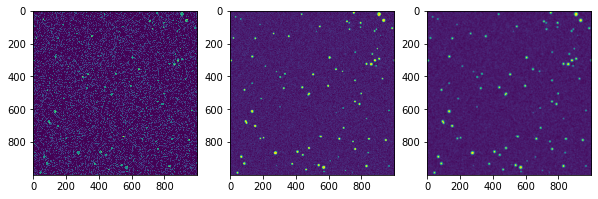

In [113]:
gaussianFilter2 = noisySimulatedChannel.getGaussianFilter(3)
_=dcc.Channel.multiChannelDisplay([noisySimulatedChannel, gaussianFilter, gaussianFilter2])

It is better, but we can see that we lost some precision with the edges of the circles. Gaussian filter (also known as gaussian blur) is good when there is not too much noise. Our previous example was quite noisy. Let's try with less noise:

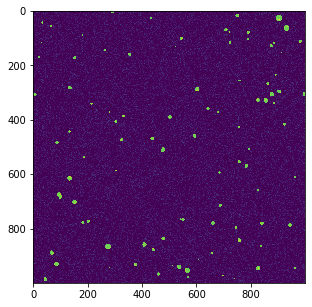

In [114]:
lessNoisySimulatedChannel = simulatedChannel.applyGaussianNoise(sigma=0.08, mean=0)
_=lessNoisySimulatedChannel.display()

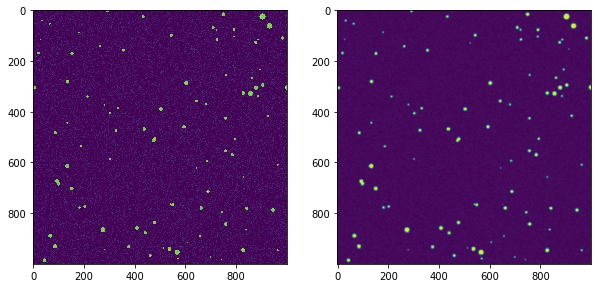

In [115]:
gaussianFilterLessNoise = lessNoisySimulatedChannel.getGaussianFilter(2)
_=dcc.Channel.multiChannelDisplay([lessNoisySimulatedChannel, gaussianFilterLessNoise])

Wow! It looks really good. But can we denoise images with other algorithms? Sure. We can use morphological methods. Let's see them in action with our very noisy channel. First of all, let's use morphological opening. This algorithm removes white noise by applying some kind of filter. The size of the filter matters because it specify what is the maximum size of the grains we want to remove. Opening is the inverse of closing, which removes small black holes by filling them. It is usefull to fill components.

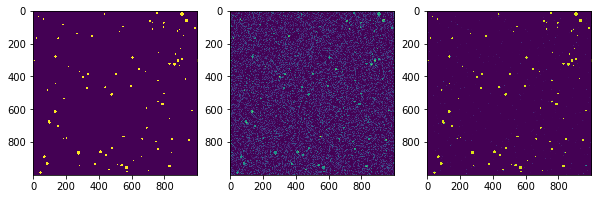

In [116]:
openingFilter = noisySimulatedChannel.getOpening()
_=dcc.Channel.multiChannelDisplay([simulatedChannel, noisySimulatedChannel, openingFilter])

We can then try erosion. It is another morphological algorithm, but simpler than opening/closing (opening is the dilation of the erosion, while closing is the erosion of dilation). Erosion shrinks bright regions and enlarges dark regions, while dilation does the inverse.

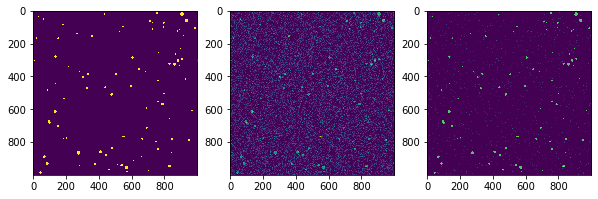

In [117]:
erosionFilter = noisySimulatedChannel.getErosion()
_=dcc.Channel.multiChannelDisplay([simulatedChannel, noisySimulatedChannel, erosionFilter])

It is not so bad, but worse than the opening. Like I said, opening uses dilation after erosion, so it first of all removes white noise and shrinks the other components but then dilation enlarges those shrinked components. That's why we get better results by applying opening.

Filtering is often essential to image analysis. There are other filters that we can use. In fact, there exist as many filters as we want. You can build your own filter if you want! The fundamental principle behind filtering is convolution (or Fourier transform, but that will come later. Also, don't panic if you've never heard about convolution. If you read about it and doesn't understand anything, it's ok. I didn't understand it either until I applied it to image analysis... a few months ago... more than a year after I heard about it for the first time...). Convolution is quite simple when we apply it to images. Just think about it this way: take your grayscale image (which is a $N\times M$ matrix) and take another smaller matrix (which is preferably square and with odd height & width. Let's take a $C\times C$ matrix with $C \leq N \land C\leq M$). Then, you slide the smaller matrix (the kernel/window) over the image and apply some mathematical equation. See the gif below (taken from https://towardsdatascience.com/intuitively-understanding-convolutions-for-deep-learning-1f6f42faee1)
![Alt Text](https://miro.medium.com/max/700/1*Fw-ehcNBR9byHtho-Rxbtw.gif)

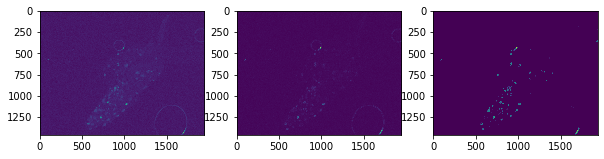

In [118]:
stdDevFilter = firstChannel.getStandardDeviationFilter(5) # Slides a small window which size is specified as a parameter.
# This filter computes the local standard deviation of the element "under" the window. 
entropyFilter = firstChannel.getEntropyFilter(7) # Same thing as the std deviation filter, but computes local entropy
_=dcc.Channel.multiChannelDisplay([firstChannel, stdDevFilter, entropyFilter])

There is also a special part in our hearts for edge detection filters/algorithms. These are really useful in machine learning for feature extraction and other things (line detection for self-driven cars or robots, etc). `dcclab` contains 2 edge detection filters (not counting the Hough transform, more info to come) : the Canny edge detection filter and the Sobel filter. The latter is simple, it is just the convolution of the original channel with two simple matrices (one for horizontal lines, the other for vertical lines). The Canny filter is more complex, because it uses a filter based on the derivative of a Gaussian and hysterisis thresholding.

To demonstrate the power of the Sobel and the Canny filters, let's create another simulation. Let's create oblique lines (which can be compared to fiber-like structures).

In [119]:
def fiberLikeStructures(arrayShape:tuple, avgLength:float, stdDevLength:float, avgThickness:float, stdDevThickness:float,
                       avgSpacing:float, stdDevSpacing:float, nbLines:int) -> np.ndarray:
    spacings = np.abs(np.random.normal(avgSpacing, stdDevSpacing, nbLines)).astype(np.uint16)
    startingX = np.round(np.cumsum(np.zeros((nbLines,)) + spacings)).astype(np.uint16)
    startingY = np.abs(np.random.normal(arrayShape[0] // 8, arrayShape[0] // 16, nbLines)).astype(np.uint16)
    startingPoints = zip(startingX, startingY)
    lengths = np.abs(np.random.normal(avgLength, stdDevLength, nbLines)).astype(np.uint16)
    thicknesses = np.ceil(np.abs(np.random.normal(avgThickness, stdDevThickness, nbLines))).astype(np.uint8)
    angles = np.random.choice(np.arange(92 / 180 * np.pi, 98 / 180 * np.pi, 0.005),
                              nbLines)
    finishingPosX = (np.cos(angles) * lengths).astype(int) + startingX
    finishingPosY = (np.sin(angles) * lengths).astype(int) + startingY
    finishingPoints = zip(finishingPosX, finishingPosY)
    array = np.zeros(arrayShape)
    for initialPoints, finalPoints, thickness in zip(startingPoints, finishingPoints, thicknesses):
        cv.line(array, initialPoints, finalPoints, 1, thickness)

    return array

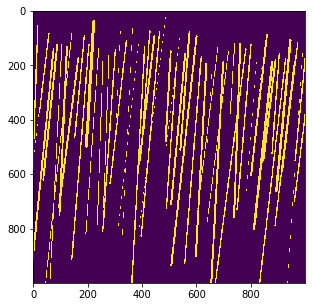

In [120]:
simulatedFibers = fiberLikeStructures((1000, 1000), 600, 200, 3, 2, 20, 3, 70)
simulatedFibersImage = dcc.Image(simulatedFibers)
simulatedFibersImage.display()

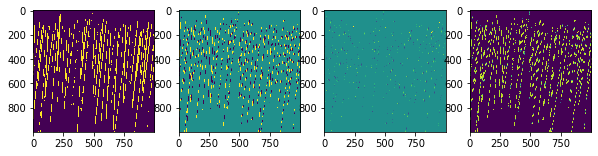

In [121]:
simulatedFibersChannel = simulatedFibersImage[0]
sobelHFilter = simulatedFibersChannel.getHorizontalSobelFilter()
sobelVFilter = simulatedFibersChannel.getVerticalSobelFilter()
sobelBoth = simulatedFibersChannel.getSobelFilter()
_=dcc.Channel.multiChannelDisplay([simulatedFibersChannel, sobelHFilter, sobelVFilter, sobelBoth])

As you can see, the second image on display (the vertical Sobel filter) is really good at detecting almost vertical lines, while the horizontal one is not very good. The Sobel filter for both direction is simply $S_{hv} = \sqrt{S_h^2 + S_v^2}$

In [122]:
#TODO add Canny when on master

Two last interesting filters : the x and y derivative filters. They kind of act like edge detection filters, because edges are significant contrast difference between two regions and significant change of contrast means a high derivative value. Let's compare them with the other filters.

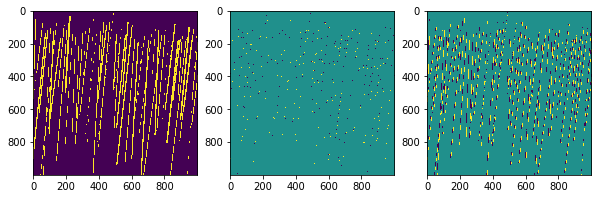

In [123]:
xDerivative = simulatedFibersChannel.getXAxisDerivative()
yDerivative = simulatedFibersChannel.getYAxisDerivative()
_=dcc.Channel.multiChannelDisplay([simulatedFibersChannel, xDerivative, yDerivative])

The main difference between the Sobel filters and the derivative filters is in the matrices used for the convolution. The horizontal Sobel filter is $$S_v = \left[\begin{array}{ccc} 
1 & 2& 1\\
-1 & -2 & -1
\end{array}\right]
$$while the horizontal derivative kernel is $$\Delta_x = \left[\begin{array}{ccc} 
-1 & 0& 1\\
\end{array}\right]$$
For the vertical ones, just transpose them.

## Fourier analysis and spectral filtering
For those who are not familiar with the Fourier transform, it is quite an interesting but complex subject. The Fourier transform is a mathematical transformation. The main idea behind it is to represent functions by an infinite sum of complex exponential. The definition (in 1D, continuous) is
$$F(\omega) = \frac{1}{\sqrt{2\pi}}\int_{-\infty}^\infty f(t)e^{-i\omega t}dt$$
where $F$ is the Fourier transform and $f$ is the original function. We can see that because we integrate over $dt$, the Fourier transform does not depend on the original variable. There are also some properties of the Fourier transform, but the most important to us is the convolution property, which states that the product of the Fourier transform of two functions is the convolution of the two original functions:
$$f * g = F(f\cdot g)$$
where $*$ denotes the convolution.

Since channels are not continuous and are in 2D, we must use the discrete Fourier transform. The definition of the 2D dirscrete Fourier transform is
$$F(u,v) = \sum_{m=0}^M\sum_{n=0}^Nf(m,n)e^{-2i\pi\left(\frac{um}{M}+\frac{vn}{N}\right)}$$
where $M,N$ are the dimensions of the original channel, $u,v$ are the shape of the Fourier transform array. When computing the Fourier transform on a channel or image, we go from the spatial dimension. Instead of having measures in pixels, we get measures in pixels${}^{-1}$. Let's look at some basic examples:

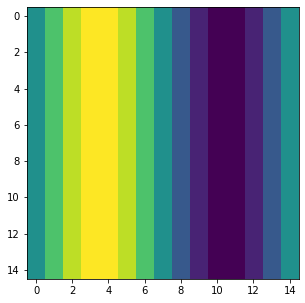

In [124]:
array = (np.sin([np.linspace(0, 2*np.pi, 15)for _ in range(15)]) + 1) / 2 # We put it between 0 and 1
channel = dcc.Image(array)[0]
_=channel.display()

As we can see, we have a sine wave in the horizontal axis. Since it only varies horizontaly, we should only have horizontal frequencies after computing the Fourier transform.

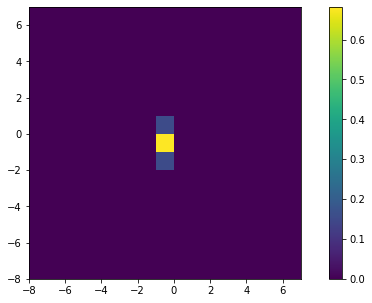

In [125]:
_=channel.displayPowerSpectrum(False)
#FIXME because of some problem of transposition, we don't see the power spectrum in the rigth orientation.

Because the Fourier transform can contain complex numbers, we usually display the *power spectrum*, which is just the squared norm of the Fourier transform coefficients. The shown power spectrum is normalized so it sums to 1 (approximatively one because of computer limitations). It is important to note that the power spectrum is centered around the low frequencies, hence the further we go from the center of the image, the higher the frequencies are. The argument of the method specify if we show the power spectrum in logarithmic scale. If we take our previous czi file, the power spectrum should look more interesting.

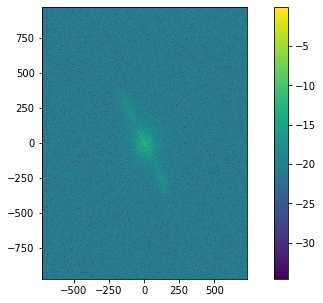

In [126]:
_=firstChannel.displayPowerSpectrum()

The power spectrum can show some funny patterns:

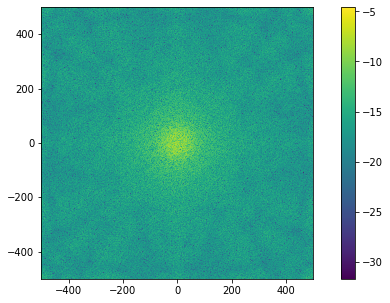

In [127]:
_= simulatedChannel.displayPowerSpectrum()

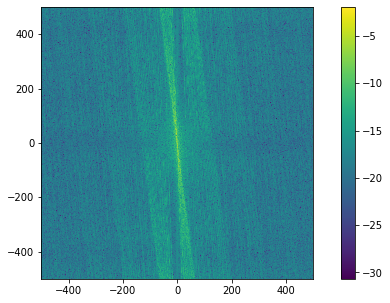

In [128]:
_= simulatedFibersChannel.displayPowerSpectrum()

We can see that some specific shapes have very specific spectral signature. Also, the amount of noise in the image changes the look of the power spectrum. Since noise is mostly very small parts contrasting with the rest, it adds some high frequencies to the spectrum. Let's see it in action:

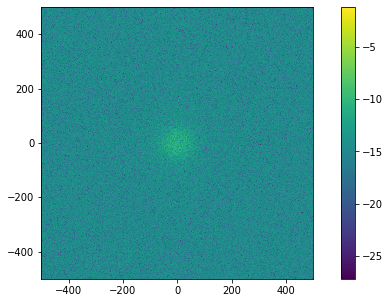

In [129]:
_= noisySimulatedChannel.displayPowerSpectrum()

As we can see, there is less low frequencies and more high frequencies. But like I said earlier, we can use filters to remove noise, and since filtering is just the convolution of the channel with a certain matrix, it should be easy to do in the frequency domain (remember the convolution property?). Like every other methods used earlier, `dcclab` offers some spectral filtering tools: low pass filters, high pass filters and bandpass filters. Let's compare some of them:

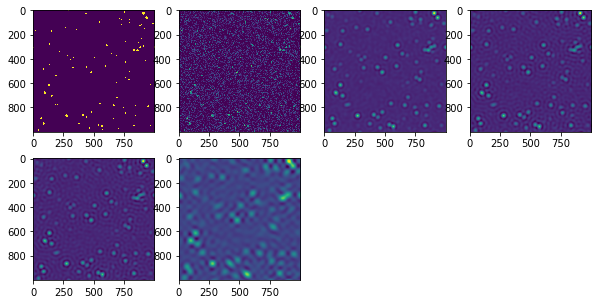

In [134]:
sigmoidFilter = noisySimulatedChannel.applyLowPassFilterFromSigmoidMask(topRadius=30)
circularFilter = noisySimulatedChannel.applyLowPassFilterFromCircularMask(radius=30)
rectangularFilter = noisySimulatedChannel.applyLowPassFilterFromRectangularMask(filterSize=30)
_=dcc.Channel.multiChannelDisplay([simulatedChannel,noisySimulatedChannel, sigmoidFilter, circularFilter, rectangularFilter])

As you can see, the resulting channels have some kind of ring around structure. This is because of the filters we applied. They are artifacts of the convolutions. We can try to obtain better results by changing some parameters. `applyLowPassFilterFromSigmoidMask` takes one more argument, which is the inflexion point slope of the sigmoid. By definition, the sigmoid function is
$$\sigma(x) = \frac{1}{1+e^{-\lambda x}}$$
where $\frac{\lambda}{4}$ is the slope of the sigmoid at its inflexion point. The steeper the slope is, the more important the ring effect is. By default, it is $\frac{1}{4}$.

The same mechanics are used by the high pass filters, but instead of removing noise, they amlify it. We can compare the low pass ones to filters keeping only the necessary information about the image (the general shapes), while the high pass filter can be compared to filters keeping only the fast-changing information (like edges, sharp changes of contrast). For bandpass filters, they take a cut in frequency and a cut off frequency (the cut in frequency is the lowest frequency we want to allow, while the cut off is the highest one). For example, when using a bandpass filter with a sigmoid mask, we specify two different radii. The same logic goes with the other bandpass filters.

We are not quite done yet with spectral analysis. Another interesting thing to look at is the azimuthal average and the angular average. When using polar coordinates $(r, \theta)$, $r$ is the radius and $\theta$ is the azimuth. The azimuthal average is just the average of the power spectrum over $360^\circ$, so over the whole azimuth. We can also say that it is the average for all the possible radii. For the angular average, it is just the average of the power spectrum for every angle between $0$ and $180^\circ$ (we dont need over 360 degrees because of the symmetry). These two different averaging methods can show interesting pattern about the power spectrum.

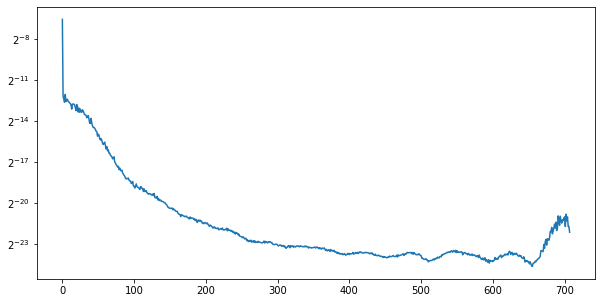

In [135]:
_= simulatedChannel.displayPowerSpectrumAzimuthalAverage(2)

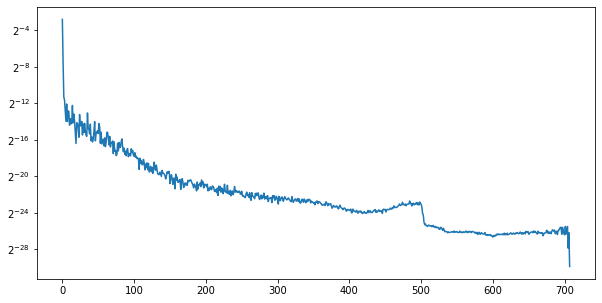

In [136]:
_= simulatedFibersChannel.displayPowerSpectrumAzimuthalAverage(2)

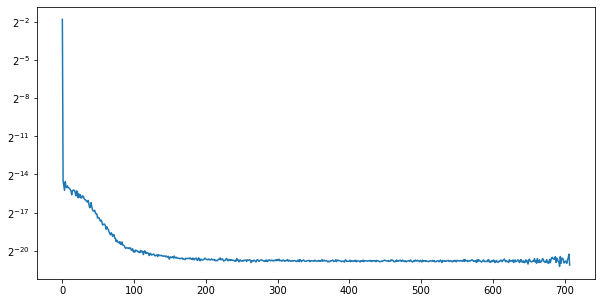

In [137]:
_= noisySimulatedChannel.displayPowerSpectrumAzimuthalAverage(2)

We can see that the azimuthal average is a good indication of the amount of noise in our channel. When we compare `simulatedChannel`'s power spectrum azimuthal average to `noisySimulatedChannel`'s power spectrum azimuthal average, we can see that it is flatter for the noisy one, and that the original (no noise) one is decreasing softer. For the angular average:

In [139]:
#TODO add angular average displays when on master

In [141]:
# Talk about peak for orientation.

## Segmentation

`dcclab` has a few methods for segmentation. They are relatively basic, like watershed and blob detection. There is also the linear Hough transfrom, which can be used for segementation but it is mostly only a line detection algorithm (like edge detection filters). Let's take a look at the watershed algorithm. It is based on the idea that we can represent the initial image with a topographic map. The higher the intensity of the pixel is, the higher the mountain is. It is a quite interesting analogy and it works (with some parameter tweeking, unfortunately). There are a few steps involved with the watershed, but they are all wrapped in an easy to use method. Let's take again our circles:

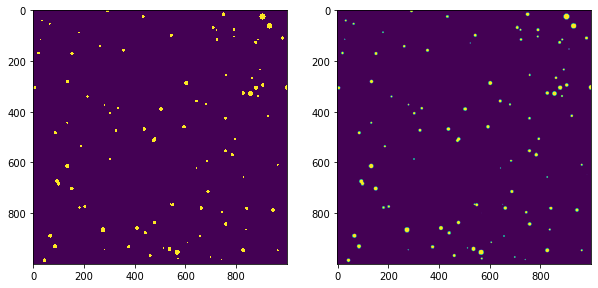

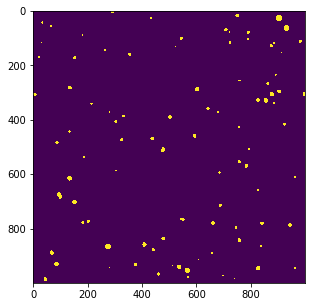

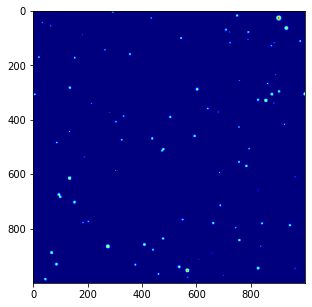

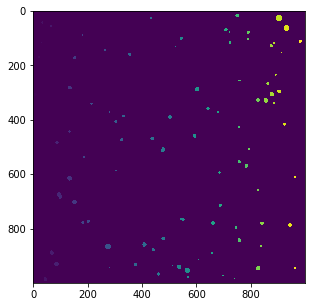

92

In [146]:
watershedMask, numberOfObject=simulatedChannel.watershedSegmentation()
_=watershedMask.display()
numberOfObject

As you can see, without setting any parameter (keeping those by default) we get a pretty good result (92 circles were detected instead of 100). We can try to play with the parameters to try to find a better segmentation.

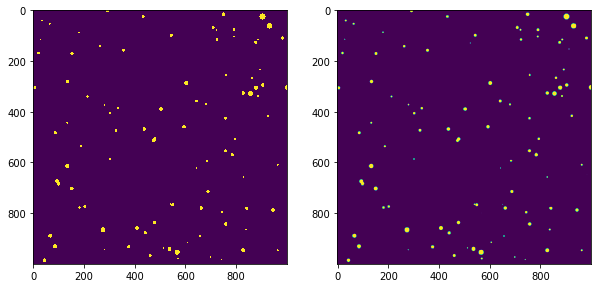

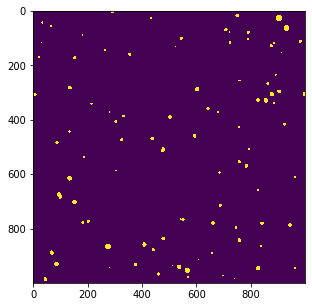

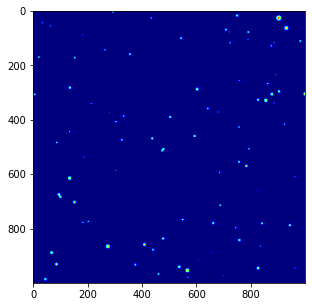

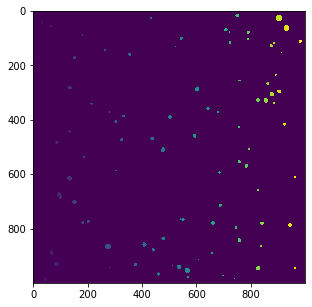

95

In [148]:
watershedMask, numberOfObject=simulatedChannel.watershedSegmentation(gaussianFilterStdDev=1, localPeaksMinDistance=3, 
                                                                     use4Connectivity=False)
_=watershedMask.display()
numberOfObject

We've got a slightly better result, but it is maybe the best it can be rigth now.

In [163]:
# see with the Allen institute segmentation.